# 04 — Statistical Analysis

**Goal:** Put numbers on the relationships between weather and fire size.

## What is correlation?
A **correlation coefficient** measures how strongly two variables move together, on a scale from −1 to +1.
- **Positive** (e.g. +0.3): when one goes up, the other tends to go up.
- **Negative** (e.g. −0.3): when one goes up, the other tends to go down.
- **Near 0**: no consistent straight-line (or ranked) relationship.

We use two versions:
- **Pearson r** measures a *straight-line* relationship using the actual values. It is very sensitive to extreme
  values, a problem here because a few fires burned hundreds of thousands of acres.
- **Spearman ρ (rho)** first converts values to *ranks* (1st, 2nd, 3rd…) and then correlates the ranks.
  It measures whether one variable tends to increase as the other increases, even if not in a straight line,
  and extreme values can't dominate it. **This makes Spearman the better fit for skewed fire sizes.**

## Correlation is not causation
Even a strong correlation doesn't prove that one variable *causes* the other. For example, hot days are also
the days in summer when vegetation is driest, more people are outdoors, and lightning storms occur. Any of those
could explain part of a temperature–fire-size relationship. This project is **observational**, so we describe
associations only.

In [1]:
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

sys.path.append("../src")
from analysis import WEATHER_COLUMNS, correlation_table, summarize_by_bins
from visualization import set_chart_style, save_figure, BLUE, ORANGE

set_chart_style()
wildfires = pd.read_csv("../data/processed/wildfires_with_weather.csv", parse_dates=["discovery_date"])
print(wildfires.shape)

(251880, 23)


## 1. Correlation with raw fire size vs. log fire size

Why log-transform? `log_fire_size = log(1 + acres)` compresses the huge range: 0.1 acres → 0.10, 100 acres → 4.6,
100,000 acres → 11.5. This stops the few giant fires from controlling the result.
Spearman is unaffected by the log (ranks don't change), but Pearson changes a lot.

In [2]:
raw = correlation_table(wildfires, "fire_size_acres").set_index("variable")
logged = correlation_table(wildfires, "log_fire_size").set_index("variable")

correlations = pd.DataFrame({
    "pearson_raw_acres": raw["pearson_r"],
    "pearson_log_acres": logged["pearson_r"],
    "spearman": logged["spearman_rho"],
    "n_fires": logged["n"],
}).round(3)
correlations.to_csv("../results/correlations_with_fire_size.csv")
correlations

,pearson_raw_acres,pearson_log_acres,spearman,n_fires
variable,,,,
temp_max_f,0.014,0.113,0.130,251880
relative_humidity,-0.019,-0.107,-0.103,251880
wind_speed_mph,-0.000,0.056,0.059,251880
precip_mm,-0.002,-0.034,-0.065,251880
precip_prev_7day_mm,-0.006,-0.045,-0.060,251880


**Rule of thumb for |correlation|:** under 0.1 ≈ negligible, 0.1–0.3 weak, 0.3–0.5 moderate, above 0.5 strong.

With ~250,000 fires, even tiny correlations would be "statistically significant", so a p-value would tell us
little. The **size** of the correlation is what matters, which is why we don't focus on significance tests here.

## 2. Correlation heatmap (Spearman)

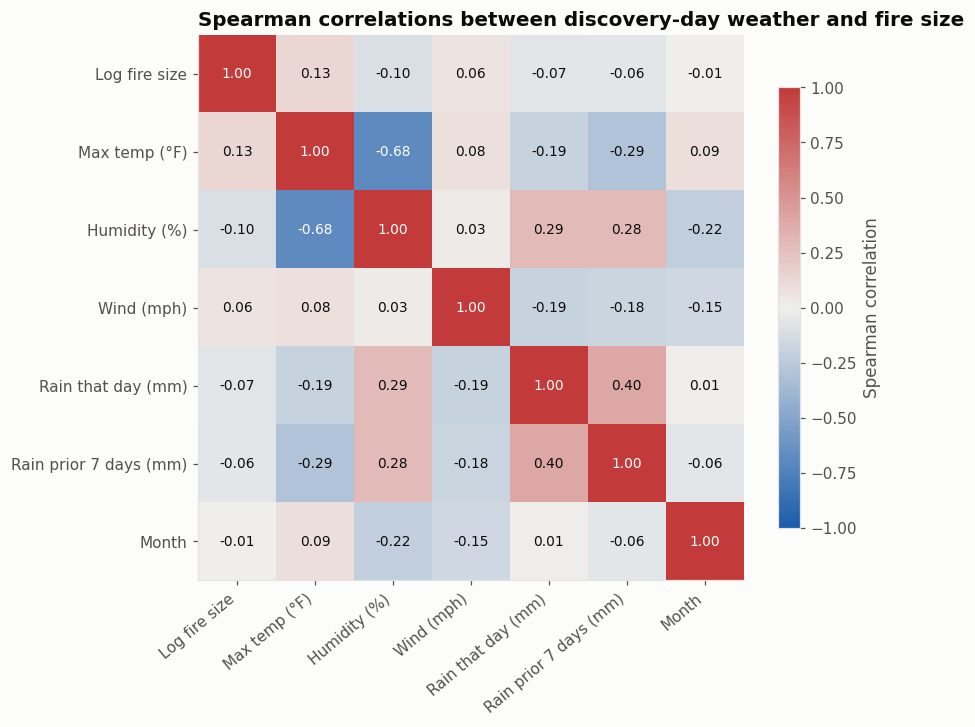

In [3]:
heatmap_columns = ["log_fire_size"] + WEATHER_COLUMNS + ["fire_month"]
labels = ["Log fire size", "Max temp (°F)", "Humidity (%)", "Wind (mph)", "Rain that day (mm)",
          "Rain prior 7 days (mm)", "Month"]
spearman_matrix = wildfires[heatmap_columns].corr(method="spearman")

# Blue = negative, red = positive, light gray = zero.
diverging = LinearSegmentedColormap.from_list("blue_gray_red", ["#1c5cab", "#f0efec", "#c23a3a"])

fig, ax = plt.subplots(figsize=(8, 6.5))
image = ax.imshow(spearman_matrix, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=40, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        value = spearman_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value) > 0.6 else "#0b0b0b")
fig.colorbar(image, ax=ax, label="Spearman correlation", shrink=0.8)
ax.set_title("Spearman correlations between discovery-day weather and fire size")
save_figure(fig, "09_correlation_heatmap.png")
plt.show()

Look at the **top row** (log fire size vs. each weather variable), and also at how strongly the weather variables
relate to *each other*. Temperature and humidity are strongly linked (hot days tend to be dry), so their separate
effects are hard to untangle.

## 3. Share of fires that became large, by weather decile

Correlation summarizes everything into one number. Another view: split fires into 10 equal-sized groups (deciles)
by a weather variable and compute the **% that grew to 100+ acres** in each group.

In [4]:
decile_tables = {}
for column in ["temp_max_f", "relative_humidity", "wind_speed_mph", "precip_prev_7day_mm"]:
    decile_tables[column] = summarize_by_bins(wildfires, column, "fire_size_acres")
decile_tables["temp_max_f"].round(3)

,bin_median,median_fire_acres,share_large,n_fires
0,59.144,0.10,0.009,25234
1,68.036,0.10,0.010,25197
2,73.949,0.11,0.016,25238
3,78.692,0.20,0.017,25106
4,82.778,0.20,0.022,25317
5,86.558,0.20,0.023,25099
6,90.122,0.25,0.025,25170
7,93.704,0.30,0.028,25238
8,97.754,0.30,0.031,25155
9,103.532,0.30,0.034,25126


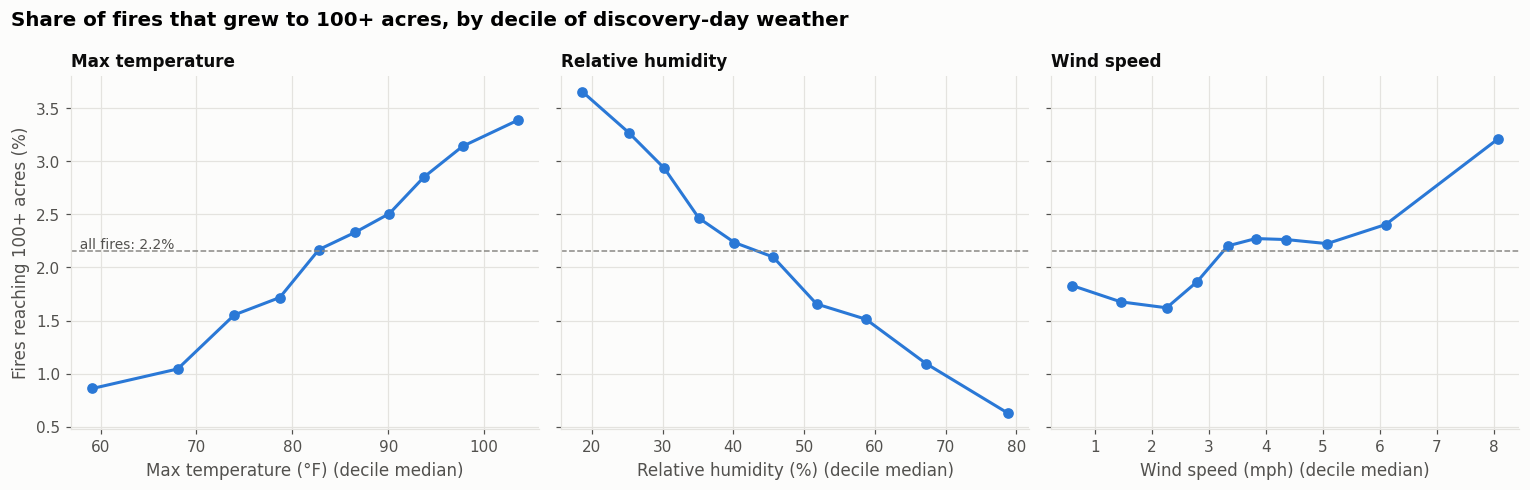

In [5]:
panels = [
    ("temp_max_f", "Max temperature (°F)"),
    ("relative_humidity", "Relative humidity (%)"),
    ("wind_speed_mph", "Wind speed (mph)"),
]
overall_share = wildfires["is_large_fire"].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, (column, label) in zip(axes, panels):
    table = decile_tables[column]
    ax.plot(table["bin_median"], table["share_large"] * 100, color=BLUE, linewidth=2, marker="o", markersize=6)
    ax.axhline(overall_share, color="#8a8985", linewidth=1, linestyle="--")
    ax.set_xlabel(label + " (decile median)")
    ax.set_title(label.split(" (")[0], fontsize=11)
axes[0].set_ylabel("Fires reaching 100+ acres (%)")
axes[0].text(axes[0].get_xlim()[0], overall_share, f"  all fires: {overall_share:.1f}%", va="bottom",
             color="#52514e", fontsize=9)
fig.suptitle("Share of fires that grew to 100+ acres, by decile of discovery-day weather", x=0.01, ha="left",
             fontweight="bold", fontsize=13)
fig.tight_layout()
save_figure(fig, "10_share_large_by_weather_decile.png")
plt.show()

## 4. Hot + dry + windy days

Fire weather is usually described as a *combination*: hot **and** dry **and** windy.
We define each condition relative to this dataset:
- **Hot:** max temperature in the top 25% of fire days
- **Dry:** relative humidity in the bottom 25%
- **Windy:** wind speed in the top 25%

Then we count how many of the three conditions each fire's discovery day met (0–3).

In [6]:
hot_cutoff = wildfires["temp_max_f"].quantile(0.75)
dry_cutoff = wildfires["relative_humidity"].quantile(0.25)
windy_cutoff = wildfires["wind_speed_mph"].quantile(0.75)
print(f"Hot:   max temp >= {hot_cutoff:.1f} F")
print(f"Dry:   humidity <= {dry_cutoff:.1f} %")
print(f"Windy: wind     >= {windy_cutoff:.1f} mph")

wildfires["is_hot"] = wildfires["temp_max_f"] >= hot_cutoff
wildfires["is_dry"] = wildfires["relative_humidity"] <= dry_cutoff
wildfires["is_windy"] = wildfires["wind_speed_mph"] >= windy_cutoff
wildfires["conditions_met"] = wildfires[["is_hot", "is_dry", "is_windy"]].sum(axis=1)

fire_weather = wildfires.groupby("conditions_met").agg(
    number_of_fires=("fire_id", "count"),
    median_acres=("fire_size_acres", "median"),
    share_large_pct=("is_large_fire", "mean"),
    total_acres=("fire_size_acres", "sum"),
)
fire_weather["share_large_pct"] = fire_weather["share_large_pct"] * 100
fire_weather.round(2).to_csv("../results/hot_dry_windy_summary.csv")
fire_weather.round(2)

Hot:   max temp >= 93.7 F
Dry:   humidity <= 30.2 %
Windy: wind     >= 5.1 mph


,number_of_fires,median_acres,share_large_pct,total_acres
conditions_met,,,,
0,120106,0.11,1.37,5506617.60
1,82058,0.21,2.44,6784988.11
2,42099,0.30,3.61,7777737.88
3,7617,0.25,3.48,857577.91


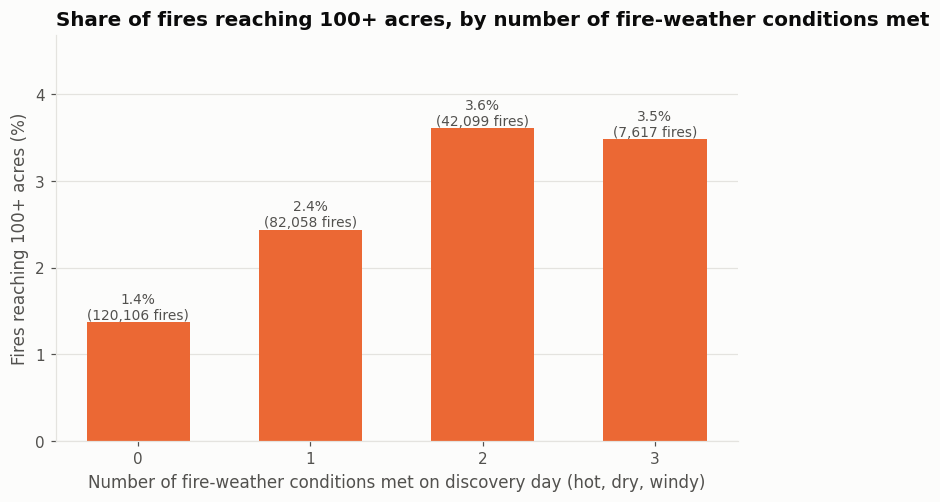

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(fire_weather.index.astype(str), fire_weather["share_large_pct"], color=ORANGE, width=0.6)
for x, (share, count) in enumerate(zip(fire_weather["share_large_pct"], fire_weather["number_of_fires"])):
    ax.text(x, share, f"{share:.1f}%\n({count:,} fires)", ha="center", va="bottom", fontsize=9, color="#52514e")
ax.set_title("Share of fires reaching 100+ acres, by number of fire-weather conditions met")
ax.set_xlabel("Number of fire-weather conditions met on discovery day (hot, dry, windy)")
ax.set_ylabel("Fires reaching 100+ acres (%)")
ax.set_ylim(0, fire_weather["share_large_pct"].max() * 1.3)
ax.grid(axis="x", visible=False)
save_figure(fig, "11_hot_dry_windy.png")
plt.show()

**What this shows:** fires discovered on days meeting none of the three conditions reached 100+ acres 1.4% of the
time; with one condition, 2.4%; with two, 3.6%. Days meeting all three (3.5%) were *not* higher than two, and they
are rarer (about 7,600 fires), so we should not claim the risk keeps rising with every added condition.

Even in the highest group, over 96% of fires stayed under 100 acres. Weather is associated with fire size, but it
is far from the whole story.

Below, the same table broken down by each specific combination:

In [8]:
wildfires.groupby(["is_hot", "is_dry", "is_windy"]).agg(
    number_of_fires=("fire_id", "count"),
    share_large_pct=("is_large_fire", "mean"),
).assign(share_large_pct=lambda table: (table["share_large_pct"] * 100).round(2))

number_of_fires  share_large_pct
is_hot is_dry is_windy                                  
False  False  False              120106             1.37
              True                41583             2.21
       True   False               22484             2.66
              True                 4601             5.28
True   False  False               17991             2.68
              True                 9183             3.02
       True   False               28315             3.52
              True                 7617             3.48

Interesting detail: the highest share (about 5.3%) is **dry + windy but not hot**, above hot + dry + windy.
One possible explanation (not tested here) is fall wind events such as Santa Ana and Diablo winds, which bring
very dry, windy air on days that are not always the hottest. Group sizes also differ a lot, so small differences
between groups should not be over-interpreted.

## 5. Summary of the statistical analysis

- All weather–fire size correlations are **weak** (|Spearman ρ| ≤ 0.13).
- Directions match expectations: larger fires are associated with **higher temperature**, **lower humidity**,
  **stronger wind** (very weak), and **less recent rain**.
- Pearson correlation on raw acres is near zero for every variable, because a few enormous fires dominate it.
  After the log transform, Pearson and Spearman agree closely.
- Looking at the **share of fires reaching 100+ acres** shows the pattern more clearly than correlation does:
  about 0.9% in the coolest tenth of fire days vs. 3.4% in the hottest tenth, and about 3.7% in the driest tenth
  of humidity vs. 0.6% in the most humid. Wind shows a weaker, less consistent pattern.
- Fires on days meeting two or three "fire-weather" conditions reached 100+ acres about 2.5 times as often (3.5–3.6%)
  as fires on days meeting none (1.4%).
- Even so, the large majority of fires stay small under every weather condition we measured.